In [16]:
import pandas as pd
from scipy import stats

url = "https://raw.githubusercontent.com/nkmwicz/data-for-students/refs/heads/main/airbnb_data.csv"
df = pd.read_csv(url)
df.head(1)

/var/folders/cc/k2w3n13x3sndt6mbgq0813c40000gp/T/ipykernel_99898/830414063.py:5: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(url)


,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,$193,10.0,9.0,10/19/2021,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN


In [17]:
print(df.columns.tolist())


['id', 'NAME', 'host id', 'host_identity_verified', 'host name', 'neighbourhood group', 'neighbourhood', 'lat', 'long', 'country', 'country code', 'instant_bookable', 'cancellation_policy', 'room type', 'Construction year', 'price', 'service fee', 'minimum nights', 'number of reviews', 'last review', 'reviews per month', 'review rate number', 'calculated host listings count', 'availability 365', 'house_rules', 'license']


In [18]:
df["price"] = df["price"].replace(r'[\$,]', '', regex=True).astype(float)

In [22]:
df = df[["price", "reviews per month"]]

r, p = stats.pearsonr(df["price"], df["reviews per month"])
r2 = r**2
print(f"r={r:.4f}, p={p:.4f}, r2={r2:.4f}")

r=0.0042, p=0.2183, r2=0.0000


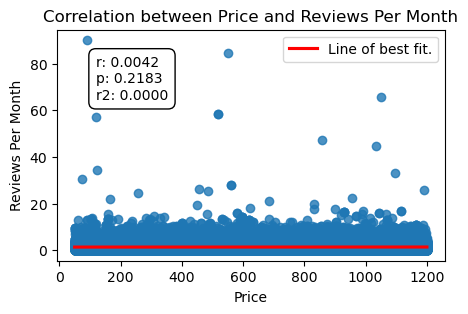

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

df = df[["price", "reviews per month"]]

x = "price"
y = "reviews per month"

r, p = stats.pearsonr(df[x], df[y])
r2 = r**2

text = f"""r: {r:.4f}
p: {p:.4f}
r2: {r2:.4f}"""

plt.figure(figsize=(5, 3))
xlabel = x.replace("_", " ").title()
ylabel = y.replace("_", " ").title()
title = f"Correlation between {xlabel} and {ylabel}"

reg = sns.regplot(data=df, x=x, y=y, line_kws={"color": "red", "label": "Line of best fit."})
reg.text(
    0.1,
    0.7,
    text,
    transform=reg.transAxes,
    bbox={"boxstyle": "round,pad=0.5", "fc": "white"}
)
reg.set(title=title, xlabel=xlabel, ylabel=ylabel)
plt.legend()
plt.show()